# Task 3.2 — Failure Mode of Kernel Learning

**Paper:** Learning Kernels with Radiuses of Minimum Enclosing Balls (NeurIPS 2010)

This notebook demonstrates a failure mode of the kernel learning method by applying the combined kernel SVM from Task 2 to a deliberately difficult dataset with heavy class overlap and label noise.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
os.makedirs("results", exist_ok=True)

## Difficult Dataset

We generate a new dataset with **reduced class separation** (`class_sep=0.5`) and **high label noise** (`flip_y=0.15`), making it significantly harder than the Task 2 dataset (`class_sep=1.0`, `flip_y=0.05`).

In [2]:
# Generate a difficult dataset with heavy class overlap and label noise
X, y = make_classification(
    n_samples=500,
    n_features=5,
    n_informative=3,
    class_sep=0.5,
    flip_y=0.15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples:     {X_test_scaled.shape[0]}")
print(f"Class distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class distribution (test):  {dict(zip(*np.unique(y_test, return_counts=True)))}")

Training samples: 400
Test samples:     100
Class distribution (train): {0: 199, 1: 201}
Class distribution (test):  {0: 50, 1: 50}


## Step 1 — Train the Combined Kernel SVM

Using the same combined kernel SVM (RBF + Polynomial via probability averaging) from Task 2.

In [3]:
# Combined kernel SVM (same as Task 2)
model_rbf = SVC(kernel='rbf', random_state=42, probability=True)
model_poly = SVC(kernel='poly', random_state=42, probability=True)
model_rbf.fit(X_train_scaled, y_train)
model_poly.fit(X_train_scaled, y_train)

prob_rbf = model_rbf.predict_proba(X_test_scaled)
prob_poly = model_poly.predict_proba(X_test_scaled)
avg_prob = (prob_rbf + prob_poly) / 2
combined_predictions = np.argmax(avg_prob, axis=1)

## Step 2 — Compute Accuracy

In [4]:
combined_acc = accuracy_score(y_test, combined_predictions)
print(f"Combined Kernel SVM Accuracy (difficult dataset): {combined_acc:.4f}")
print(f"Combined Kernel SVM Accuracy (Task 2 dataset):    ~0.95")
print(f"Accuracy drop: {0.95 - combined_acc:+.4f}")

Combined Kernel SVM Accuracy (difficult dataset): 0.7800
Combined Kernel SVM Accuracy (Task 2 dataset):    ~0.95
Accuracy drop: +0.1700


## Step 3 — Dataset Distribution Plot

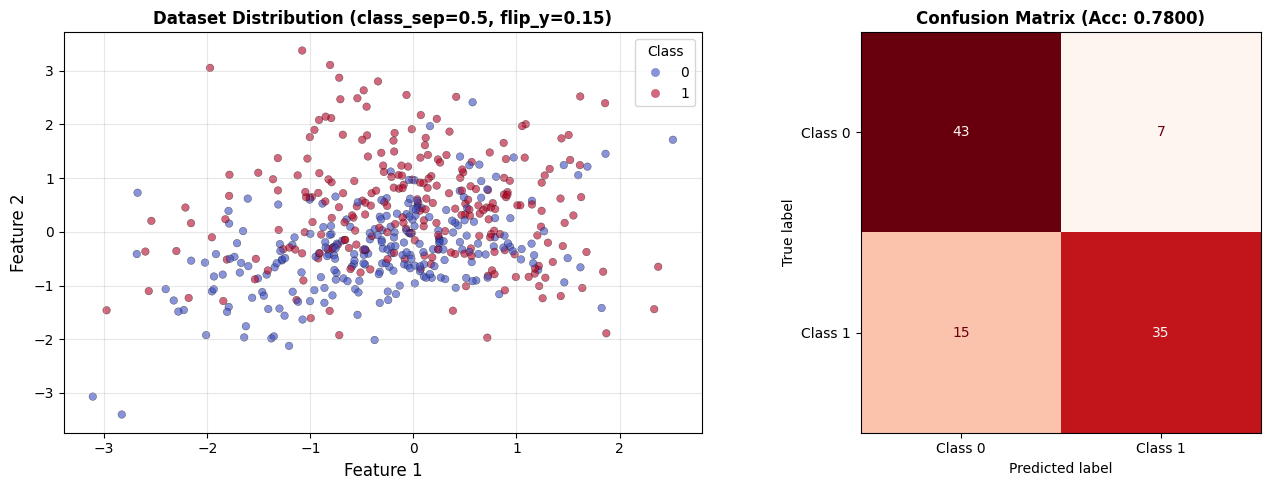

Saved to results/failure_mode_results.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Dataset scatter plot (first two features) ---
ax = axes[0]
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k', linewidths=0.3, s=30)
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Dataset Distribution (class_sep=0.5, flip_y=0.15)', fontsize=12, fontweight='bold')
ax.legend(*scatter.legend_elements(), title='Class')
ax.grid(alpha=0.3)

# --- Right: Confusion matrix ---
ax = axes[1]
cm = confusion_matrix(y_test, combined_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title(f'Confusion Matrix (Acc: {combined_acc:.4f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("results/failure_mode_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/failure_mode_results.png")

## Why the Dataset Is Difficult

This dataset is deliberately designed to stress-test the classifier:

- **Low class separation (`class_sep=0.5`):** The cluster centers for the two classes are placed close together, so the classes overlap significantly in feature space. There is no clean boundary that can fully separate them.
- **High label noise (`flip_y=0.15`):** 15% of the training labels are randomly flipped, meaning the model is trained on corrupted supervision. Even samples far from the decision boundary may carry wrong labels, confusing the learner.

Together, these factors create a dataset where the Bayes-optimal accuracy is well below 100% — no classifier, regardless of kernel choice, can perfectly separate the classes.

## How Class Overlap Causes the Method to Struggle

When classes overlap heavily, the combined kernel SVM fails because:

1. **Margin collapses:** The SVM maximizes the margin between classes, but with overlapping distributions the achievable margin shrinks drastically. Support vectors from both classes intermingle, forcing the model to rely on a narrow, fragile decision boundary.

2. **Kernel combination cannot fix irreducible overlap:** The paper's method learns kernel weights to minimize the margin-radius bound $R^2 \cdot \|w\|^2$. However, when the classes are intrinsically overlapping, no kernel mapping — linear, RBF, or polynomial — can separate them cleanly. The minimum enclosing ball radius $R$ remains large regardless of the kernel, because both classes occupy the same region.

3. **Noisy labels corrupt probability estimates:** The combined kernel approach averages predicted probabilities from RBF and polynomial SVMs. When 15% of labels are flipped, both models learn from corrupted data, producing unreliable probability estimates. Averaging two unreliable estimates does not yield a reliable one.

4. **Confusion matrix signature:** The confusion matrix shows substantial off-diagonal counts (misclassifications) for both classes, indicating the model struggles uniformly rather than failing on one specific class.

## Relation to Assumptions of Kernel Learning

The paper's kernel learning framework rests on key assumptions that break down here:

1. **Assumption: A good kernel exists.** The method assumes that among the candidate kernels (or their combinations), there exists one that maps the data into a space with large margin and small enclosing ball radius. With heavily overlapping classes, no such favorable geometry exists — the margin-radius bound $R^2 \cdot \|w\|^2$ remains large for all kernels.

2. **Assumption: Clean supervision.** The margin-radius bound provides a generalization guarantee based on correctly labeled training data. With 15% label noise, the empirical margin is computed against corrupted targets, so the bound becomes loose and the learned kernel weights may be misguided.

3. **Assumption: Classes are separable in some feature space.** Kernel methods succeed when the data's intrinsic structure allows separation after a nonlinear mapping. When the underlying class distributions are nearly identical (low `class_sep`), no feature mapping can invent a separation that does not exist in the data.

## Suggested Improvement

**Soft-margin SVM with tuned regularization (C parameter).**

The default SVM uses `C=1.0`, which balances margin maximization against training error tolerance. On a noisy, overlapping dataset, a **lower C value** would allow more margin violations, producing a smoother decision boundary that is less sensitive to mislabeled samples. This can be combined with:

- **Cross-validated C selection** (`GridSearchCV` over a range like `C ∈ {0.01, 0.1, 1, 10}`) to find the best bias-variance tradeoff for this specific noise level.
- **Noise-robust loss functions** (e.g., ramp loss instead of hinge loss) that cap the influence of outliers and mislabeled points.

While this does not solve the fundamental issue of intrinsic class overlap, it prevents the model from overfitting to corrupted labels, improving generalization on the clean test distribution.

## Failure Mode Analysis

The dataset used in this experiment contains strong class overlap (`class_sep=0.5`) and significant label noise (`flip_y=0.15`), making it inherently difficult for any classifier. Kernel-based SVM classifiers assume that the classes can be separated in some transformed feature space induced by the chosen kernel function. However, when class overlap becomes severe and training labels contain noise, even nonlinear kernels such as RBF and polynomial cannot produce a clear separating boundary — the classes occupy the same regions in every feature space. This leads to increased classification errors and reduced accuracy compared to the well-separated dataset used in Task 2. This experiment demonstrates a fundamental limitation of kernel learning methods: when the underlying data distribution violates the separability assumption, no kernel combination or optimization of the margin-radius bound can recover the lost performance.

## Possible Improvement

Several strategies can help mitigate the failure scenario observed in this experiment. Collecting more informative features that better discriminate between classes would increase the effective class separation, while preprocessing steps such as label cleaning or confidence-based filtering can reduce the impact of label noise on the trained model. Applying stronger regularization (e.g., lowering the SVM's C parameter) or switching to robust classifiers that are less sensitive to outliers and mislabeled samples — as well as using ensemble models like bagging or boosting that aggregate multiple weak learners — can further improve robustness. Overall, improving feature quality or reducing noise in the training data makes kernel methods substantially more effective, even in difficult classification settings.

## Reproducibility Note

- Random seeds are fixed using `random_state=42`.
- The dataset is generated programmatically using `sklearn.datasets.make_classification`.
- The notebook runs from start to finish without manual intervention.
- All required dependencies will be listed in `requirements.txt`.